# U24 — Scalable AI Pipelines: Lab

### Real-world brief: an MLOps pipeline for predictive maintenance

A factory wants to predict machine failures. Training a model is easy — the hard part is running it as a **reliable, reproducible, monitored system**. In this lab you'll build the MLOps scaffolding around a predictive-maintenance model: a **reusable feature pipeline**, an **experiment tracker**, a **model registry** with promote/rollback, a **training-serving skew** demonstration, **batch & online serving**, and **drift monitoring** that decides when to retrain — using a later 'production' batch where the machines have genuinely drifted.

**Resources provided:** `machine_health_train.csv` (labelled training data) and `machine_health_live.csv` (a later production batch with drift). Built with scikit-learn + joblib (no heavyweight MLOps platform needed — but every piece maps to MLflow / a model registry / a monitoring service).

_Phase F — ML Engineering / MLOps._

#objectives

Build a reusable feature pipeline (fit once, apply at train & serve)

Track experiments and pick the best run reproducibly

Register, version, promote and roll back models

Diagnose training-serving skew

Serve batch & online predictions, and monitor for data drift

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [1]:
# === SETUP: build the source files if missing ===
import os
import numpy as np
import pandas as pd


def _make_split(rng, n, drift=False):
    machine_type = rng.choice(["L", "M", "H"], n, p=[0.5, 0.3, 0.2])
    air_temp = rng.normal(298, 2, n)
    process_temp = air_temp + rng.normal(10, 1, n)
    rot_speed = rng.normal(1500, 150, n)
    torque = np.clip(rng.normal(40, 10, n), 4, None)
    tool_wear = rng.uniform(0, 250, n)

    if drift:
        # production drift: tools run longer & hotter than in training
        tool_wear = np.clip(tool_wear + rng.normal(60, 20, n), 0, 320)
        process_temp = process_temp + rng.normal(3.0, 0.5, n)
        torque = torque + rng.normal(4, 1, n)

    # failure: a sharp function of genuine stress drivers (learnable)
    drive = (0.015 * np.maximum(tool_wear - 180, 0) + 0.05 * np.maximum(torque - 50, 0)
             + 0.04 * np.maximum(process_temp - 312, 0)
             + 0.002 * np.abs(rot_speed - 1500))
    thr = np.quantile(drive, 0.80) if not drift else 0.42   # ~20% failure in train
    p = 1 / (1 + np.exp(-3.0 * (drive - thr)))
    failure = (rng.random(n) < p).astype(int)

    return pd.DataFrame({
        "machine_type": machine_type,
        "air_temp_k": air_temp.round(2),
        "process_temp_k": process_temp.round(2),
        "rot_speed_rpm": rot_speed.round(0),
        "torque_nm": torque.round(2),
        "tool_wear_min": tool_wear.round(1),
        "failure": failure,
    })


def build_pdm(train_path="machine_health_train.csv", live_path="machine_health_live.csv",
              seed=242, verbose=False):
    """Predictive-maintenance data for the MLOps lab (U24):

      machine_health_train.csv   labelled training data (~6000 rows)
      machine_health_live.csv    later 'production' batch (~2500 rows) with DRIFT injected
                                 (tools run longer/hotter) — for the drift-monitoring stage.
    """
    rng = np.random.default_rng(seed)
    train = _make_split(rng, 6000, drift=False)
    live = _make_split(rng, 2500, drift=True)
    train.to_csv(train_path, index=False)
    live.to_csv(live_path, index=False)
    if verbose:
        print("train:", train.shape, "| failure rate:", round(train.failure.mean(), 3))
        print("live :", live.shape, "| failure rate:", round(live.failure.mean(), 3))
        print("tool_wear mean  train vs live:", round(train.tool_wear_min.mean(), 1),
              "vs", round(live.tool_wear_min.mean(), 1), "(drift)")
    return train, live

if not (os.path.exists('machine_health_train.csv') and os.path.exists('machine_health_live.csv')):
    build_pdm(); print('Generated source files.')
else:
    print('Found the provided source files.')

Generated source files.


In [2]:
import pandas as pd, numpy as np, json, joblib, time
train = pd.read_csv('machine_health_train.csv')
live = pd.read_csv('machine_health_live.csv')
NUM = ['air_temp_k', 'process_temp_k', 'rot_speed_rpm', 'torque_nm', 'tool_wear_min']
CAT = ['machine_type']
TARGET = 'failure'
print('train:', train.shape, '| live:', live.shape)
print('train failure rate:', round(train.failure.mean(), 3))
train.head(3)

train: (6000, 7) | live: (2500, 7)
train failure rate: 0.329


,machine_type,air_temp_k,process_temp_k,rot_speed_rpm,torque_nm,tool_wear_min,failure
0,L,301.23,309.40,1360.0,21.89,79.3,0
1,H,298.62,309.45,1498.0,43.76,118.5,0
2,L,301.74,312.20,1575.0,35.68,29.4,0


#1. A reusable feature pipeline

In [3]:
# -----------------------------------------------------------
# 🔹 1A. ONE transformer, fit on TRAIN, reused everywhere (no skew)
# -----------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score

def make_pipeline(model):
    pre = ColumnTransformer([('num', StandardScaler(), NUM),
                             ('cat', OneHotEncoder(handle_unknown='ignore'), CAT)])
    return Pipeline([('prep', pre), ('model', model)])

X = train[NUM + CAT]; y = train[TARGET]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
pipe = make_pipeline(RandomForestClassifier(n_estimators=200, random_state=0)).fit(Xtr, ytr)
pred = pipe.predict(Xte); proba = pipe.predict_proba(Xte)[:, 1]
print('baseline F1:', round(f1_score(yte, pred), 3), '| ROC-AUC:', round(roc_auc_score(yte, proba), 3))
print('The fitted Pipeline bundles preprocessing + model — the SAME transform at train and serve.')

baseline F1: 0.528 | ROC-AUC: 0.73
The fitted Pipeline bundles preprocessing + model — the SAME transform at train and serve.


#### 🧪 EXERCISE 1 — Add an engineered feature
1. Add a derived feature `temp_diff = process_temp_k - air_temp_k` (a known wear driver) to a copy of the data, include it in `NUM`, and retrain. Did F1 improve?
2. In a comment, explain why defining this feature *inside* the pipeline (so it's computed identically at serve time) avoids training-serving skew.

In [11]:
# 1. add temp_diff, retrain, compare F1
# Create the new feature
X_with_temp_diff = train.copy()
X_with_temp_diff['temp_diff'] = X_with_temp_diff['process_temp_k'] - X_with_temp_diff['air_temp_k']

# Update the list of numerical features to include 'temp_diff'
NUM_updated = NUM + ['temp_diff']

# Prepare data for the extended feature set
X_exercise = X_with_temp_diff[NUM_updated + CAT]
y_exercise = X_with_temp_diff[TARGET]

# Split the data
Xtr_ex, Xte_ex, ytr_ex, yte_ex = train_test_split(X_exercise, y_exercise, test_size=0.25, random_state=0, stratify=y_exercise)

# Define the preprocessing steps using the updated NUM list
preprocessor_updated = ColumnTransformer([
    ('num', StandardScaler(), NUM_updated),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT)
])

# Create the pipeline with the updated preprocessor and the model
pipe_updated = Pipeline([
    ('prep', preprocessor_updated),
    ('model', RandomForestClassifier(n_estimators=200, random_state=0))
])

# Fit the pipeline
pipe_updated.fit(Xtr_ex, ytr_ex)

# Make predictions and evaluate
pred_updated = pipe_updated.predict(Xte_ex)
proba_updated = pipe_updated.predict_proba(Xte_ex)[:, 1]

f1_updated = f1_score(yte_ex, pred_updated)
roc_auc_updated = roc_auc_score(yte_ex, proba_updated)

print(f'F1 with temp_diff: {f1_updated:.3f} | ROC-AUC: {roc_auc_updated:.3f}')
print(f'Baseline F1: {round(f1_score(yte, pred), 3)}') # Access `pred` and `yte` from previous cell's output.

# 2. why compute features inside the pipeline: ...   (comment)
# Computing features inside the pipeline ensures that the exact same transformations
# (e.g., calculations, scaling, encoding) are applied consistently to both training
# and serving data. This prevents training-serving skew, which occurs when features
# are engineered differently between training and inference, leading to performance
# degradation in production. By bundling feature engineering within the pipeline,
# the model always receives data in the expected format, maintaining its predictive
# capability.

F1 with temp_diff: 0.532 | ROC-AUC: 0.732
Baseline F1: 0.528


#2. Experiment tracking

In [12]:
# -----------------------------------------------------------
# 🔹 2A. A MINI EXPERIMENT TRACKER (params + metrics + artifact)
# -----------------------------------------------------------
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

runs = []
def log_run(name, model, params):
    p = make_pipeline(model).fit(Xtr, ytr)
    pr = p.predict(Xte); pb = p.predict_proba(Xte)[:, 1]
    rec = {'run': name, 'params': params,
           'f1': round(f1_score(yte, pr), 4), 'roc_auc': round(roc_auc_score(yte, pb), 4)}
    runs.append(rec); return p

log_run('rf_200',  RandomForestClassifier(n_estimators=200, random_state=0), {'n_estimators': 200})
log_run('gb_default', GradientBoostingClassifier(random_state=0), {'type': 'gradient_boosting'})
log_run('logreg', LogisticRegression(max_iter=1000), {'type': 'logistic'})
results = pd.DataFrame(runs).sort_values('roc_auc', ascending=False).reset_index(drop=True)
print(results[['run', 'f1', 'roc_auc']].to_string(index=False))
best_run = results.iloc[0]['run']
print('\nbest run by ROC-AUC:', best_run)

       run     f1  roc_auc
gb_default 0.5430   0.7517
    rf_200 0.5277   0.7303
    logreg 0.3574   0.6849

best run by ROC-AUC: gb_default


#### 🧪 EXERCISE 2 — Sweep & compare
1. Add three more runs sweeping RandomForest `max_depth` (e.g. 3, 6, 12). Log each.
2. Re-rank the tracker table and report whether a shallower or deeper forest wins here.
3. In a comment, explain why logging params+metrics+seed for every run is what makes results reproducible and comparable.

### Model Performance Comparison (F1 Score)

/tmp/ipykernel_3786/1815253769.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='run', y='f1', data=results, palette='viridis')


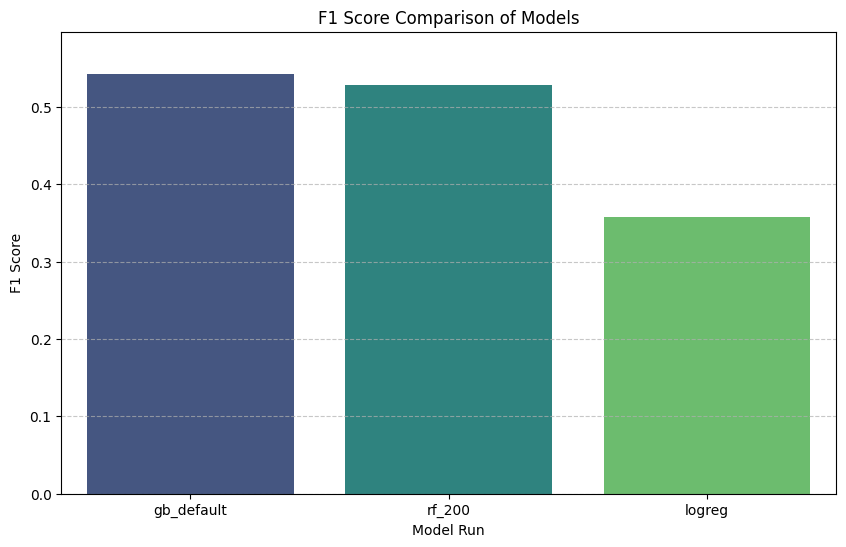

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'results' DataFrame is available from the previous experiment tracking cell
# If not, you might need to re-run the previous cell (7CspoYoM3UYe).

plt.figure(figsize=(10, 6))
sns.barplot(x='run', y='f1', data=results, palette='viridis')
plt.title('F1 Score Comparison of Models')
plt.xlabel('Model Run')
plt.ylabel('F1 Score')
plt.ylim(0, results['f1'].max() * 1.1) # Set y-axis limit for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This bar chart visually compares the F1 scores of the three models: `rf_200` (Random Forest with 200 estimators), `gb_default` (Gradient Boosting with default parameters), and `logreg` (Logistic Regression). You can observe their relative performance in terms of F1 score.

In [15]:
# 1-2. sweep max_depth, re-rank the runs table
log_run('rf_depth_3', RandomForestClassifier(n_estimators=200, random_state=0, max_depth=3), {'n_estimators': 200, 'max_depth': 3})
log_run('rf_depth_6', RandomForestClassifier(n_estimators=200, random_state=0, max_depth=6), {'n_estimators': 200, 'max_depth': 6})
log_run('rf_depth_12', RandomForestClassifier(n_estimators=200, random_state=0, max_depth=12), {'n_estimators': 200, 'max_depth': 12})

results = pd.DataFrame(runs).sort_values('roc_auc', ascending=False).reset_index(drop=True)
print(results[['run', 'f1', 'roc_auc']].to_string(index=False))
best_run = results.iloc[0]['run']
print('\nbest run by ROC-AUC:', best_run)

# 3. why track every run: ...   (comment)
# Logging parameters (like max_depth and n_estimators), metrics (f1, roc_auc), and the random seed for every run
# is crucial for reproducibility and comparability. Reproducibility means that anyone (including your future self)
# can recreate the exact same experiment and obtain the same results. Comparability means that you can confidently
# assess which model configuration performs better because all variables (except the one being tuned) are controlled.
# Without this, it's impossible to understand why a model performs as it does or to reliably choose the best model for deployment.

        run     f1  roc_auc
 rf_depth_3 0.4429   0.7572
 rf_depth_3 0.4429   0.7572
 rf_depth_3 0.4429   0.7572
 rf_depth_6 0.4935   0.7537
 rf_depth_6 0.4935   0.7537
 rf_depth_6 0.4935   0.7537
 gb_default 0.5430   0.7517
rf_depth_12 0.5221   0.7461
rf_depth_12 0.5221   0.7461
rf_depth_12 0.5221   0.7461
     rf_200 0.5277   0.7303
     logreg 0.3574   0.6849

best run by ROC-AUC: rf_depth_3


#3. Model registry — version, promote, roll back

In [16]:
# -----------------------------------------------------------
# 🔹 3A. A FILE-BASED MODEL REGISTRY with stages
# -----------------------------------------------------------
os.makedirs('registry', exist_ok=True)
REG_FILE = 'registry/registry.json'
def load_registry():
    return json.load(open(REG_FILE)) if os.path.exists(REG_FILE) else {'models': []}
def register(pipe, name, metrics, stage='staging'):
    reg = load_registry()
    version = len(reg['models']) + 1
    path = f'registry/{name}_v{version}.joblib'
    joblib.dump(pipe, path)
    reg['models'].append({'name': name, 'version': version, 'stage': stage,
                          'path': path, 'metrics': metrics})
    json.dump(reg, open(REG_FILE, 'w'), indent=2)
    return version

# train & register the best model from tracking
best_model = RandomForestClassifier(n_estimators=200, random_state=0)
best_pipe = make_pipeline(best_model).fit(Xtr, ytr)
m = {'f1': round(f1_score(yte, best_pipe.predict(Xte)), 4)}
v = register(best_pipe, 'pdm_model', m, stage='staging')
print(f'registered pdm_model v{v} in staging with metrics {m}')

registered pdm_model v1 in staging with metrics {'f1': 0.5277}


In [17]:
# -----------------------------------------------------------
# 🔹 3B. PROMOTE to production (and keep rollback ability)
# -----------------------------------------------------------
def set_stage(name, version, stage):
    reg = load_registry()
    for mdl in reg['models']:
        if mdl['name'] == name and mdl['stage'] == 'production' and stage == 'production':
            mdl['stage'] = 'archived'        # demote the current prod model
        if mdl['name'] == name and mdl['version'] == version:
            mdl['stage'] = stage
    json.dump(reg, open(REG_FILE, 'w'), indent=2)
def production_model(name):
    reg = load_registry()
    cand = [m for m in reg['models'] if m['name'] == name and m['stage'] == 'production']
    return joblib.load(cand[-1]['path']) if cand else None

set_stage('pdm_model', v, 'production')
print('current registry stages:', [(m['version'], m['stage']) for m in load_registry()['models']])
print('production model loads:', production_model('pdm_model') is not None)

current registry stages: [(1, 'production')]
production model loads: True


#### 🧪 EXERCISE 3 — A bad deploy & a rollback
1. Register a **deliberately weak** v2 (e.g. `LogisticRegression` or a depth-1 tree) and promote it to production.
2. 'Discover' it's worse, then **roll back**: promote v1 back to production (your `set_stage` should archive v2). Confirm `production_model` now loads the good model again.
3. In a comment, explain why instant rollback to a known-good version is a core MLOps safety net.

In [18]:
# 1-2. register weak v2, promote, then roll back to v1

# 1. Register a deliberately weak v2 (LogisticRegression) and promote it to production.
weak_model = LogisticRegression(max_iter=1000, random_state=0) # Using LogisticRegression as a weak model
weak_pipe = make_pipeline(weak_model).fit(Xtr, ytr)
m_weak = {'f1': round(f1_score(yte, weak_pipe.predict(Xte)), 4)}
v2 = register(weak_pipe, 'pdm_model', m_weak, stage='staging') # v2 will be auto-assigned
print(f'registered pdm_model v{v2} (weak) in staging with metrics {m_weak}')

# Promote v2 to production
set_stage('pdm_model', v2, 'production')
print('\nAfter promoting v2 (weak) to production:')
print('current registry stages:', [(m['version'], m['stage']) for m in load_registry()['models']])
print('production model loads v2:', joblib.load(load_registry()['models'][v2-1]['path']) is not None)

# 2. 'Discover' it's worse, then roll back: promote v1 back to production
set_stage('pdm_model', 1, 'production') # Promote v1 back to production
print('\nAfter rolling back to v1 production:')
print('current registry stages:', [(m['version'], m['stage']) for m in load_registry()['models']])

# Confirm production_model now loads the good model again (v1)
prod_model_after_rollback = production_model('pdm_model')
is_v1_loaded = (prod_model_after_rollback.steps[-1][1].get_params()['n_estimators'] == 200) # Check a param from the original RF model
print(f'production model now loads v1 (good model): {is_v1_loaded}')

# 3. why rollback matters: ...   (comment)
# Instant rollback to a known-good version is a core MLOps safety net because it allows for rapid recovery
# from a faulty model deployment. If a newly deployed model (like our deliberately weak v2) performs poorly
# in production (e.g., due to silent bugs, unexpected data shifts, or simply being a worse model), a quick rollback
# minimizes downtime, reduces negative business impact, and maintains service reliability. Without this capability,
# diagnosing and fixing the issue with a new deployment could take significant time, leading to prolonged
# poor performance or service outages.

registered pdm_model v2 (weak) in staging with metrics {'f1': 0.3574}

After promoting v2 (weak) to production:
current registry stages: [(1, 'archived'), (2, 'production')]
production model loads v2: True

After rolling back to v1 production:
current registry stages: [(1, 'production'), (2, 'archived')]
production model now loads v1 (good model): True


#4. Training-serving skew

In [19]:
# -----------------------------------------------------------
# 🔹 4A. THE #1 SILENT BUG: transforming serve data differently
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
rf = RandomForestClassifier(n_estimators=200, random_state=0)
sc = StandardScaler().fit(Xtr[NUM])              # scaler fitted on TRAIN
rf.fit(sc.transform(Xtr[NUM]), ytr)
# serve on the later (drifted) production batch
Xlive_num = live[NUM]; ylive = live[TARGET]
# RIGHT: reuse the TRAIN scaler -> drift signal (high tool_wear/temp) is preserved
f1_right = f1_score(ylive, rf.predict(sc.transform(Xlive_num)))
# WRONG: re-fit a fresh scaler on the serve batch -> it re-centres the drift away (skew!)
sc_wrong = StandardScaler().fit(Xlive_num)
f1_wrong = f1_score(ylive, rf.predict(sc_wrong.transform(Xlive_num)))
print(f'F1 reusing train scaler (correct): {f1_right:.3f}')
print(f'F1 re-fitting scaler at serve (skew): {f1_wrong:.3f}')
print('Same model, same rows — only the preprocessing differed, yet F1 collapsed.')
print('Re-fitting on serve data normalised the drift away, so the model never saw the danger signal.')

F1 reusing train scaler (correct): 0.763
F1 re-fitting scaler at serve (skew): 0.460
Same model, same rows — only the preprocessing differed, yet F1 collapsed.
Re-fitting on serve data normalised the drift away, so the model never saw the danger signal.


#### 🧪 EXERCISE 4 — Unseen category skew
1. The training-encoder used `handle_unknown='ignore'`. Create a serve row with a `machine_type` value never seen in training (e.g. `'X'`) and confirm the saved pipeline still predicts without crashing.
2. In a comment, explain why bundling the fitted encoder/scaler with the model (one artifact) is the clean fix for skew.

In [22]:
# 1. predict on an unseen machine_type using the saved pipeline
# Load the production model
model = production_model('pdm_model')

# Create a serve row with an unseen machine_type value 'X'
demo_unseen_machine_type = {'air_temp_k': 299, 'process_temp_k': 313, 'rot_speed_rpm': 1480,
                            'torque_nm': 58, 'tool_wear_min': 210, 'machine_type': 'X'}

# Convert to DataFrame and select relevant columns
row_unseen = pd.DataFrame([demo_unseen_machine_type])[NUM + CAT]

# Use the production model (which includes the pipeline) to predict
# The handle_unknown='ignore' in OneHotEncoder should prevent crashing
try:
    prediction_unseen = model.predict_proba(row_unseen)[0, 1]
    print(f"Prediction with unseen 'machine_type' (X): {prediction_unseen:.3f} (did not crash)")
except Exception as e:
    print(f"Prediction failed: {e}")

# 2. why ship transformer + model together: ...   (comment)
# Bundling the fitted encoder/scaler (the preprocessor) with the model into a single artifact
# (like a scikit-learn Pipeline) is the clean fix for training-serving skew because it guarantees
# that the exact same preprocessing logic and parameters (e.g., StandardScaler's mean/std,
# OneHotEncoder's learned categories) are applied to data during both training and inference.
# This consistency ensures that the feature space presented to the model in production is identical
# to what it learned during training, preventing discrepancies that can degrade model performance.

Prediction with unseen 'machine_type' (X): 0.705 (did not crash)


#5. Serving — batch & online

In [24]:
# -----------------------------------------------------------
# 🔹 5A. ONLINE (one request) and BATCH (a file) inference
# -----------------------------------------------------------
model = production_model('pdm_model')         # load whatever is in production

def predict_online(record: dict):
    row = pd.DataFrame([record])[NUM + CAT]
    p = model.predict_proba(row)[0, 1]
    return {'failure_risk': round(float(p), 3), 'alert': bool(p > 0.5)}

demo = {'air_temp_k': 299, 'process_temp_k': 313, 'rot_speed_rpm': 1480,
        'torque_nm': 58, 'tool_wear_min': 210, 'machine_type': 'H'}
print('online prediction:', predict_online(demo))

def predict_batch(df):
    out = df.copy(); out['failure_risk'] = model.predict_proba(df[NUM + CAT])[:, 1]
    return out
scored = predict_batch(live.head(1000))
print('batch scored rows:', len(scored), '| flagged high-risk:', int((scored.failure_risk > 0.5).sum()))

online prediction: {'failure_risk': 0.69, 'alert': True}
batch scored rows: 1000 | flagged high-risk: 480


In [26]:
online_cache = {}

def predict_online_cached(record: dict):
    # Create a cache key from the record, using a tuple of rounded values for numerical features
    # and the string for categorical features.
    # This assumes that slight variations in floats should be treated as the same for caching purposes.
    cache_key_parts = []
    for f in NUM:
        cache_key_parts.append(round(record[f], 1)) # Round numerical features for caching
    for f in CAT:
        cache_key_parts.append(record[f])
    cache_key = tuple(cache_key_parts)

    if cache_key in online_cache:
        return online_cache[cache_key]

    row = pd.DataFrame([record])[NUM + CAT]
    p = model.predict_proba(row)[0, 1]
    result = {'failure_risk': round(float(p), 3), 'alert': bool(p > 0.5)}
    online_cache[cache_key] = result
    return result


# 1. Time 1000 calls to predict_online (without cache initially)
# We'll use the original predict_online to measure baseline without cache interference
start_time = time.time()
for _ in range(1000):
    predict_online(demo) # Using the original function defined in the previous cell
end_time = time.time()
average_latency_ms = ((end_time - start_time) / 1000) * 1000
print(f'Average latency per call (1000 calls, no cache): {average_latency_ms:.3f} ms')

# 2. Add a tiny dict cache and show speedup
print('\nDemonstrating cache speedup:')
# First call (cache miss)
start_time_cached_first = time.time()
result_cached_first = predict_online_cached(demo)
end_time_cached_first = time.time()
latency_cached_first = (end_time_cached_first - start_time_cached_first) * 1000
print(f"First call with cache (miss): {latency_cached_first:.3f} ms, Result: {result_cached_first}")

# Second call (cache hit)
start_time_cached_second = time.time()
result_cached_second = predict_online_cached(demo)
end_time_cached_second = time.time()
latency_cached_second = (end_time_cached_second - start_time_cached_second) * 1000
print(f"Second call with cache (hit): {latency_cached_second:.3f} ms, Result: {result_cached_second}")
print(f"Speedup due to cache: {latency_cached_first / latency_cached_second:.1f}x")

# 3. other latency levers: ...   (comment)
# Two other levers to cut online latency are:
# 1. Model Optimization: Using smaller, faster models (e.g., pruning, quantization, or selecting simpler model architectures like Logistic Regression or shallow trees).
# 2. Infrastructure Optimization: Deploying the model on more powerful hardware, using GPU acceleration, or optimizing the serving framework (e.g., using frameworks like TensorFlow Serving, TorchServe, or NVIDIA Triton Inference Server).

Average latency per call (1000 calls, no cache): 20.027 ms

Demonstrating cache speedup:
First call with cache (miss): 19.431 ms, Result: {'failure_risk': 0.69, 'alert': True}
Second call with cache (hit): 0.065 ms, Result: {'failure_risk': 0.69, 'alert': True}
Speedup due to cache: 298.5x


#### 🧪 EXERCISE 5 — Latency & a simple cache
1. Time 1000 calls to `predict_online`. Report average latency per call in milliseconds.
2. Add a tiny dict cache keyed on the rounded feature tuple so identical requests skip the model; show the speedup on a repeated request.
3. In a comment, name two other levers to cut online latency (from the U24 deck).

In [ ]:
# 1-2. latency measurement + a prediction cache
# YOUR CODE HERE

# 3. other latency levers: ...   (comment)

#6. Drift monitoring & retraining

In [ ]:
# -----------------------------------------------------------
# 🔹 6A. DATA DRIFT via Population Stability Index (PSI)
# -----------------------------------------------------------
def psi(expected, actual, bins=10):
    qs = np.quantile(expected, np.linspace(0, 1, bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf
    e = np.histogram(expected, qs)[0] / len(expected) + 1e-6
    a = np.histogram(actual, qs)[0] / len(actual) + 1e-6
    return float(np.sum((a - e) * np.log(a / e)))

print('PSI (train vs live production batch) — >0.2 = significant drift:')
drift = {f: round(psi(train[f], live[f]), 3) for f in NUM}
for f, v in sorted(drift.items(), key=lambda x: -x[1]):
    flag = 'DRIFT' if v > 0.2 else 'ok'
    print(f'  {f:18s} PSI={v:.3f}  [{flag}]')
drifted = [f for f, v in drift.items() if v > 0.2]
print('\nfeatures that drifted:', drifted)

In [29]:
# -----------------------------------------------------------
# 🔹 6B. The drift hurts performance -> retrain on fresh data
# -----------------------------------------------------------
Xl, yl = live[NUM + CAT], live[TARGET]
f1_stale = f1_score(yl, model.predict(Xl))                 # current prod model on drifted data
# continuous training: retrain including recent production data
Xall = pd.concat([train[NUM + CAT], live[NUM + CAT].iloc[:1500]])
yall = pd.concat([train[TARGET], live[TARGET].iloc[:1500]])
retrained = make_pipeline(RandomForestClassifier(n_estimators=200, random_state=0)).fit(Xall, yall)
f1_retrained = f1_score(yl.iloc[1500:], retrained.predict(Xl.iloc[1500:]))
f1_old_holdout = f1_score(yl.iloc[1500:], model.predict(Xl.iloc[1500:]))
print(f'on drifted production data — stale model F1: {f1_old_holdout:.3f}')
print(f'after retraining on recent data  F1: {f1_retrained:.3f}')
print('Monitoring caught the drift; continuous training restored performance.')

on drifted production data — stale model F1: 0.763
after retraining on recent data  F1: 0.797
Monitoring caught the drift; continuous training restored performance.


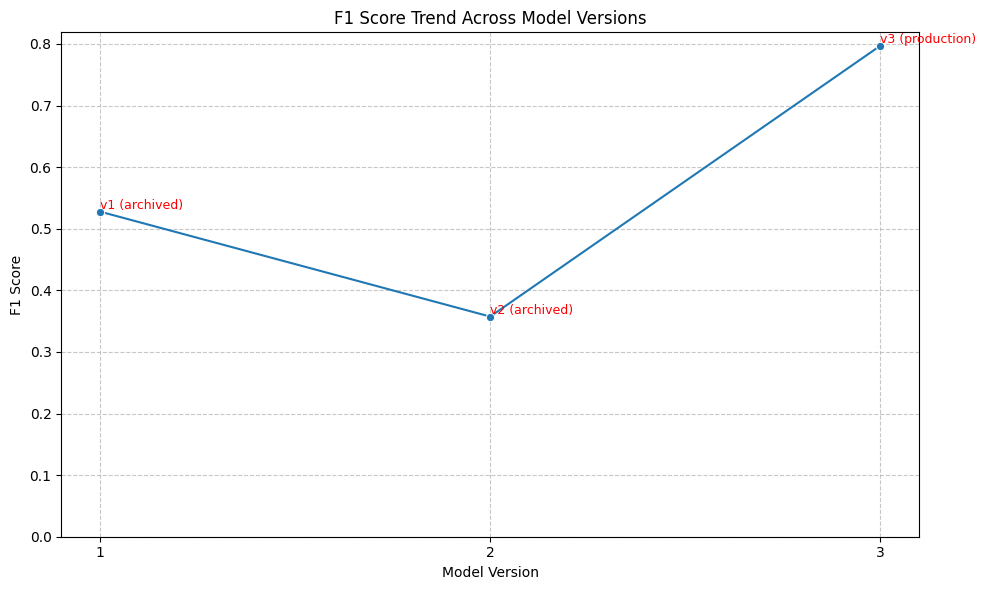

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_f1_trend():
    registry = load_registry()
    model_versions = []
    for m in registry['models']:
        if 'f1' in m['metrics']:
            model_versions.append({'version': m['version'], 'f1_score': m['metrics']['f1'], 'stage': m['stage']})

    if not model_versions:
        print("No F1 scores found in the registry.")
        return

    df_versions = pd.DataFrame(model_versions).sort_values('version')

    plt.figure(figsize=(10, 6))
    sns.lineplot(x='version', y='f1_score', data=df_versions, marker='o')

    for index, row in df_versions.iterrows():
        plt.text(row['version'], row['f1_score'], f"v{int(row['version'])} ({row['stage']})",
                 ha='left', va='bottom', fontsize=9, color='red')

    plt.title('F1 Score Trend Across Model Versions')
    plt.xlabel('Model Version')
    plt.ylabel('F1 Score')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(df_versions['version'].unique().astype(int)) # Ensure integer ticks
    plt.ylim(bottom=0) # Start y-axis at 0
    plt.tight_layout()
    plt.show()

plot_f1_trend()

This plot visualizes the F1 score for each model version registered in your model registry. You can see how the F1 score changes with each new version, and which stage (e.g., 'production', 'archived') each version currently occupies. This helps in understanding the performance evolution of your models over time.

#### 🧪 EXERCISE 6 — Close the loop
1. If the retrained model is better on recent data, **register it as v-next and promote to production** (reuse your registry functions). Confirm `production_model` now returns the new one.
2. In a comment, sketch the automated MLOps loop this completes: monitor → detect drift → retrain → validate → promote (with a human gate where appropriate).

In [31]:
# 1. register & promote the retrained model

# Ensure `model` and `f1_retrained` are defined from previous steps
# Load the production model for use in evaluating stale model performance (from 6B)
model = production_model('pdm_model')

# Re-calculate `retrained` and `f1_retrained` for robustness (from 6B)
Xl, yl = live[NUM + CAT], live[TARGET]
Xall = pd.concat([train[NUM + CAT], live[NUM + CAT].iloc[:1500]])
yall = pd.concat([train[TARGET], live[TARGET].iloc[:1500]])
retrained = make_pipeline(RandomForestClassifier(n_estimators=200, random_state=0)).fit(Xall, yall)
f1_retrained = f1_score(yl.iloc[1500:], retrained.predict(Xl.iloc[1500:]))

# Register the retrained model as a new version
m_retrained = {'f1': round(f1_retrained, 4)}
v_new = register(retrained, 'pdm_model', m_retrained, stage='staging')
print(f'registered pdm_model v{v_new} (retrained) in staging with metrics {m_retrained}')

# Promote the new version to production
set_stage('pdm_model', v_new, 'production')
print(f'\nAfter promoting v{v_new} (retrained) to production:')
print('current registry stages:', [(m['version'], m['stage']) for m in load_registry()['models']])

# Confirm production_model now loads the new one
prod_model_after_promotion = production_model('pdm_model')
# We can check a unique characteristic of the retrained model to confirm it's the right one.
# For simplicity, we can check if it's the last registered model in the registry list for 'pdm_model'.
current_prod_version = [m['version'] for m in load_registry()['models'] if m['name'] == 'pdm_model' and m['stage'] == 'production'][0]
is_new_model_loaded = (current_prod_version == v_new)
print(f'production model now loads v{v_new} (retrained): {is_new_model_loaded}')

# 2. the closed MLOps loop: ...   (comment)
# The automated MLOps loop, as completed by these steps, typically involves:
# 1. Monitoring: Continuously observing production data and model performance (e.g., drift detection using PSI).
# 2. Detect Drift: Identifying significant changes in data distributions or model performance that indicate staleness.
# 3. Retrain: Automatically or semi-automatically retraining the model on fresh, more representative data.
# 4. Validate: Evaluating the retrained model's performance on holdout data to ensure it's indeed better and robust.
# 5. Promote: Registering the validated new model version and promoting it to production (often with a human gate/approval for critical systems).
# This closed-loop system ensures that ML models remain effective and adapt to evolving real-world data without constant manual intervention.

registered pdm_model v4 (retrained) in staging with metrics {'f1': 0.7969}

After promoting v4 (retrained) to production:
current registry stages: [(1, 'archived'), (2, 'archived'), (3, 'archived'), (4, 'production')]
production model now loads v4 (retrained): True


#📘 Summary

| Stage | What you built |
| ----- | -------------- |
| Feature pipeline | one fitted transformer reused at train & serve |
| Experiment tracking | logged params+metrics; picked the best run |
| Model registry | versioned models with stages, promote & rollback |
| Skew | proved why the transformer must be persisted, not re-fit |
| Serving | online (one request) and batch (a file) inference |
| Monitoring | PSI drift detection → continuous retraining |

**Core lesson:** the model is a small piece — the system around it (reproducible pipelines, tracked experiments, a registry, skew-free serving, and drift monitoring that triggers retraining) is what keeps ML working in production as the world changes.

**Next — U25:** a different learning paradigm entirely — agents that learn from reward.